# Lineformer vs LineformerUQ Evaluation and View Rendering

This notebook evaluates **standard Lineformer** and **UQ Lineformer** on a chosen split (`val` or `cal`) from a dataset pickle, then renders projection views using the repository render pipeline (`src/render/render.py`) for side-by-side comparison with ground truth.

It reuses repository logic from:
- `src/render/render.py` (`render`, `run_network`)
- `src/network/Lineformer.py`, `src/network/LineformerUQ.py`
- `src/network/__init__.py` (`get_network`)
- `src/encoder/__init__.py` (`get_encoder`)
- `src/utils/util.py` (metrics and image casting)
- split conventions inferred from your pickle-creation snippet (`train` / `val` / `cal`, each with `angles` and `projections`).

In [4]:
import os
import sys
import shutil

env_bin = os.path.dirname(sys.executable)
os.environ["PATH"] = env_bin + os.pathsep + os.environ.get("PATH", "")

print("python:", sys.executable)
print("PATH ninja:", shutil.which("ninja"))

from torch.utils.cpp_extension import is_ninja_available
print("ninja available:", is_ninja_available())

python: /home/rd635/miniforge3/envs/sax_nerf/bin/python
PATH ninja: /home/rd635/miniforge3/envs/sax_nerf/bin/ninja
ninja available: True


In [5]:
# 1) Setup and configuration
import os
import sys
import pickle
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# =========================
# User-editable config
# =========================
REPO_ROOT = Path('/home/rd635/Conformal-SAX-NeRF')
CONFIG_PATH = REPO_ROOT / 'config/Lineformer/chest_50.yaml'
PICKLE_PATH = REPO_ROOT / 'data/chest_50_reassigned_train_val_cal.pickle'
SPLIT_NAME = 'cal'  # 'val' or 'cal'

LINEFORMER_CKPT = REPO_ROOT / 'logs/Lineformer/chest_50/2026_03_28_12_01_28/ckpt_best.tar'
LINEFORMER_UQ_CKPT = REPO_ROOT / 'logs/UncLineformer/chest_50/2026_03_26_14_47_36/ckpt_best.tar'

# Quantile used for UQ evaluation (median by default)
Q_VALUE = 0.5

# Extra quantiles for uncertainty visualization
Q_VIS = [0.1, 0.5, 0.9]

# Evaluation / rendering controls
MAX_VIEWS = 8          # number of split views to evaluate/render
VIEW_INDICES = None    # e.g. [0, 5, 10], or None for first MAX_VIEWS
N_RAYS_CHUNK = 8192    # ray chunk size during render
VOXEL_EVAL = True      # evaluate 3D volume metrics too

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE =', DEVICE)
print('REPO_ROOT =', REPO_ROOT)
print('CONFIG_PATH exists:', CONFIG_PATH.exists())
print('PICKLE_PATH exists:', PICKLE_PATH.exists())
print('LINEFORMER_CKPT exists:', LINEFORMER_CKPT.exists())
print('LINEFORMER_UQ_CKPT exists:', LINEFORMER_UQ_CKPT.exists())

DEVICE = cuda
REPO_ROOT = /home/rd635/Conformal-SAX-NeRF
CONFIG_PATH exists: True
PICKLE_PATH exists: True
LINEFORMER_CKPT exists: True
LINEFORMER_UQ_CKPT exists: True


In [6]:
# repo import setup
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config.configloading import load_config
from src.render import render, run_network
from src.network import get_network
from src.encoder import get_encoder
from src.utils import get_psnr, get_ssim, get_psnr_3d, get_ssim_3d, cast_to_image
from src.dataset.tigre import ConeGeometry, TIGREDataset

cfg = load_config(str(CONFIG_PATH))
print('Loaded config exp name:', cfg['exp']['expname'])
print('Render config:', cfg['render'])

Loaded config exp name: chest_50
Render config: {'n_samples': 256, 'n_fine': 0, 'perturb': True, 'raw_noise_std': 0.0, 'netchunk': 409600}


## 2) Inspect and load split data

Assumed split structure from your provided snippet:
- `data['train'] = {'angles', 'projections'}`
- `data['val']   = {'angles', 'projections'}`
- `data['cal']   = {'angles', 'projections'}`

For `val`, we can directly use `TIGREDataset(..., type='val')`.
For `cal`, the repo dataset class has no built-in `cal` type, so we adapt `TIGREDataset` geometry/ray logic in notebook-friendly helper functions while preserving behavior.

In [7]:
with open(PICKLE_PATH, 'rb') as f:
    data_dict = pickle.load(f)

print('Top-level keys:', sorted(data_dict.keys()))
for s in ['train', 'val', 'cal']:
    if s in data_dict:
        sub_keys = sorted(data_dict[s].keys())
        print(f"split={s}, keys={sub_keys}")
        if 'angles' in data_dict[s] and 'projections' in data_dict[s]:
            print('  angles shape:', np.asarray(data_dict[s]['angles']).shape)
            print('  projections shape:', np.asarray(data_dict[s]['projections']).shape)

assert SPLIT_NAME in ['val', 'cal'], "SPLIT_NAME must be 'val' or 'cal'"
assert SPLIT_NAME in data_dict, f"Split '{SPLIT_NAME}' not found in pickle"
assert 'angles' in data_dict[SPLIT_NAME] and 'projections' in data_dict[SPLIT_NAME], 'Split must contain angles and projections'

print('Using split:', SPLIT_NAME)

Top-level keys: ['DSD', 'DSO', 'accuracy', 'cal', 'convert', 'dDetector', 'dVoxel', 'filter', 'image', 'mode', 'nDetector', 'nVoxel', 'noise', 'normalize', 'numCal', 'numTrain', 'numVal', 'offDetector', 'offOrigin', 'randomAngle', 'rescale_intercept', 'rescale_slope', 'startAngle', 'totalAngle', 'train', 'val']
split=train, keys=['angles', 'projections']
  angles shape: (60,)
  projections shape: (60, 256, 256)
split=val, keys=['angles', 'projections']
  angles shape: (25,)
  projections shape: (25, 256, 256)
split=cal, keys=['angles', 'projections']
  angles shape: (15,)
  projections shape: (15, 256, 256)
Using split: cal


In [8]:
# Helpers adapted from src/dataset/tigre.py methods to support both val and cal
def angle2pose(DSO, angle):
    phi1 = -np.pi / 2
    R1 = np.array([[1.0, 0.0, 0.0],
                   [0.0, np.cos(phi1), -np.sin(phi1)],
                   [0.0, np.sin(phi1), np.cos(phi1)]])

    phi2 = np.pi / 2
    R2 = np.array([[np.cos(phi2), -np.sin(phi2), 0.0],
                   [np.sin(phi2), np.cos(phi2), 0.0],
                   [0.0, 0.0, 1.0]])

    R3 = np.array([[np.cos(angle), -np.sin(angle), 0.0],
                   [np.sin(angle), np.cos(angle), 0.0],
                   [0.0, 0.0, 1.0]])

    rot = R3 @ R2 @ R1
    trans = np.array([DSO * np.cos(angle), DSO * np.sin(angle), 0.0])

    T = np.eye(4)
    T[:-1, :-1] = rot
    T[:-1, -1] = trans
    return T

def get_near_far(geo, tolerance=0.005):
    dist1 = np.linalg.norm([geo.offOrigin[0] - geo.sVoxel[0] / 2, geo.offOrigin[1] - geo.sVoxel[1] / 2])
    dist2 = np.linalg.norm([geo.offOrigin[0] - geo.sVoxel[0] / 2, geo.offOrigin[1] + geo.sVoxel[1] / 2])
    dist3 = np.linalg.norm([geo.offOrigin[0] + geo.sVoxel[0] / 2, geo.offOrigin[1] - geo.sVoxel[1] / 2])
    dist4 = np.linalg.norm([geo.offOrigin[0] + geo.sVoxel[0] / 2, geo.offOrigin[1] + geo.sVoxel[1] / 2])
    dist_max = np.max([dist1, dist2, dist3, dist4])
    near = np.max([0, geo.DSO - dist_max - tolerance])
    far = np.min([geo.DSO * 2, geo.DSO + dist_max + tolerance])
    return near, far

def get_voxels(geo):
    n1, n2, n3 = geo.nVoxel
    s1, s2, s3 = geo.sVoxel / 2 - geo.dVoxel / 2
    xyz = np.meshgrid(np.linspace(-s1, s1, n1),
                      np.linspace(-s2, s2, n2),
                      np.linspace(-s3, s3, n3), indexing='ij')
    voxel = np.asarray(xyz).transpose([1, 2, 3, 0])
    return voxel

def get_rays(angles, geo, device):
    W, H = geo.nDetector
    DSD = geo.DSD
    rays_all = []

    for angle in angles:
        pose = torch.tensor(angle2pose(geo.DSO, angle), dtype=torch.float32, device=device)

        i, j = torch.meshgrid(
            torch.linspace(0, W - 1, W, device=device),
            torch.linspace(0, H - 1, H, device=device),
            indexing='ij',
        )

        if geo.mode == 'cone':
            uu = (i.t() + 0.5 - W / 2) * geo.dDetector[0] + geo.offDetector[0]
            vv = (j.t() + 0.5 - H / 2) * geo.dDetector[1] + geo.offDetector[1]
            dirs = torch.stack([uu / DSD, vv / DSD, torch.ones_like(uu)], -1)
            rays_d = torch.sum(torch.matmul(pose[:3, :3], dirs[..., None]), -1)
            rays_o = pose[:3, -1].expand(rays_d.shape)
        elif geo.mode == 'parallel':
            uu = (i.t() + 0.5 - W / 2) * geo.dDetector[0] + geo.offDetector[0]
            vv = (j.t() + 0.5 - H / 2) * geo.dDetector[1] + geo.offDetector[1]
            dirs = torch.stack([torch.zeros_like(uu), torch.zeros_like(uu), torch.ones_like(uu)], -1)
            rays_d = torch.sum(torch.matmul(pose[:3, :3], dirs[..., None]), -1)
            rays_o = torch.sum(
                torch.matmul(pose[:3, :3], torch.stack([uu, vv, torch.zeros_like(uu)], -1)[..., None]), -1
            ) + pose[:3, -1].expand(rays_d.shape)
        else:
            raise NotImplementedError('Unknown CT scanner mode')

        rays_all.append(torch.cat([rays_o, rays_d], dim=-1))

    return torch.stack(rays_all, dim=0)

def build_split_tensors_from_pickle(data_dict, split_name, device):
    geo = ConeGeometry(data_dict)
    near, far = get_near_far(geo)

    split = data_dict[split_name]
    angles = np.asarray(split['angles'])
    projs_np = np.asarray(split['projections'])

    projs = torch.tensor(projs_np, dtype=torch.float32, device=device)
    rays = get_rays(angles, geo, device=device)
    rays = torch.cat([
        rays,
        torch.ones_like(rays[..., :1]) * near,
        torch.ones_like(rays[..., :1]) * far
    ], dim=-1)

    image = torch.tensor(np.asarray(data_dict['image']), dtype=torch.float32, device=device)
    voxels = torch.tensor(get_voxels(geo), dtype=torch.float32, device=device)

    return {
        'split_name': split_name,
        'angles': angles,
        'projs': projs,      # [N, H, W]
        'rays': rays,        # [N, H, W, 8]
        'image': image,      # [D, H, W]
        'voxels': voxels,    # [D, H, W, 3]
        'near': near,
        'far': far,
    }

# val uses built-in dataset path; cal uses inferred split structure from your snippet
if SPLIT_NAME == 'val':
    dset_val = TIGREDataset(str(PICKLE_PATH), cfg['train']['n_rays'], 'val', str(DEVICE))
    split_data = {
        'split_name': 'val',
        'angles': np.asarray(data_dict['val']['angles']),
        'projs': dset_val.projs.to(DEVICE),
        'rays': dset_val.rays.to(DEVICE),
        'image': dset_val.image.to(DEVICE),
        'voxels': dset_val.voxels.to(DEVICE),
        'near': dset_val.near,
        'far': dset_val.far,
    }
else:
    split_data = build_split_tensors_from_pickle(data_dict, 'cal', DEVICE)

print('split:', split_data['split_name'])
print('projs shape:', tuple(split_data['projs'].shape))
print('rays shape:', tuple(split_data['rays'].shape))
print('image shape:', tuple(split_data['image'].shape))
print('voxels shape:', tuple(split_data['voxels'].shape))
print('near/far:', split_data['near'], split_data['far'])
print('sample angles:', split_data['angles'][:5])

split: cal
projs shape: (15, 256, 256)
rays shape: (15, 256, 256, 8)
image shape: (128, 128, 128)
voxels shape: (128, 128, 128, 3)
near/far: 0.9044903320081219 1.0955096679918779
sample angles: [0.9424778 1.1154796 1.1938052 1.2294954 1.2566371]


## 3) Model loading

Model construction follows the same code path as training: `get_network(...)` + `get_encoder(...)`, then checkpoint keys `network` / `network_fine`.

- Standard model: `Lineformer`
- UQ model: `UQLineformer` (selected automatically by `get_network('Lineformer', unc=True)`)

UQ inference uses quantile input via `render(..., quantiles=...)` in `src/render/render.py`.

In [9]:
def build_model_and_fine(cfg, uncertainty=False, device=DEVICE):
    encoder = get_encoder(**cfg['encoder'])
    network_ctor = get_network(cfg['network']['net_type'], uncertainty)

    net_kwargs = dict(cfg['network'])
    net_kwargs.pop('net_type', None)

    net = network_ctor(encoder, **net_kwargs).to(device)
    net_fine = None
    if cfg['render']['n_fine'] > 0:
        net_fine = network_ctor(encoder, **net_kwargs).to(device)
    return net, net_fine

def load_checkpoint_into_models(ckpt_path, net, net_fine=None, map_location='cpu'):
    ckpt = torch.load(str(ckpt_path), map_location=map_location)
    state_main = ckpt['network'] if 'network' in ckpt else ckpt
    msg_main = net.load_state_dict(state_main, strict=False)

    msg_fine = None
    if net_fine is not None and 'network_fine' in ckpt and ckpt['network_fine'] is not None:
        msg_fine = net_fine.load_state_dict(ckpt['network_fine'], strict=False)

    return ckpt, msg_main, msg_fine

# Standard Lineformer
net_std, net_std_fine = build_model_and_fine(cfg, uncertainty=False, device=DEVICE)
ckpt_std, msg_std_main, msg_std_fine = load_checkpoint_into_models(LINEFORMER_CKPT, net_std, net_std_fine, map_location=DEVICE)

# UQ Lineformer
net_uq, net_uq_fine = build_model_and_fine(cfg, uncertainty=True, device=DEVICE)
ckpt_uq, msg_uq_main, msg_uq_fine = load_checkpoint_into_models(LINEFORMER_UQ_CKPT, net_uq, net_uq_fine, map_location=DEVICE)

net_std.eval()
if net_std_fine is not None:
    net_std_fine.eval()
net_uq.eval()
if net_uq_fine is not None:
    net_uq_fine.eval()

print('Standard checkpoint epoch:', ckpt_std.get('epoch', 'N/A'))
print('UQ checkpoint epoch:', ckpt_uq.get('epoch', 'N/A'))
print('Standard load msg:', msg_std_main)
print('UQ load msg:', msg_uq_main)
if net_std_fine is not None: print('Standard fine load msg:', msg_std_fine)
if net_uq_fine is not None: print('UQ fine load msg:', msg_uq_fine)

Standard checkpoint epoch: 1500
UQ checkpoint epoch: 1500
Standard load msg: <All keys matched successfully>
UQ load msg: <All keys matched successfully>


## 4) Evaluation on selected split

Evaluation follows `train_mlg.py` style:
- Flatten split rays and render in chunks with `render(...)`
- Compute projection metrics (`PSNR`, `SSIM`)
- Optionally compute 3D volume metrics with `run_network(...)`

Difference for UQ path:
- pass per-ray quantiles (`q`) into `render(..., quantiles=q_chunk)`
- pass per-voxel quantiles into `run_network(..., quantiles=vox_q)`

In [10]:
@torch.no_grad()
def predict_split_projections(net, net_fine, rays_split, render_cfg, n_rays_chunk=8192, q_value=None):
    # rays_split: [N, H, W, 8]
    N, H, W, _ = rays_split.shape
    rays_flat = rays_split.reshape(-1, 8)

    pred_chunks = []
    for i in tqdm(range(0, rays_flat.shape[0], n_rays_chunk), desc='Rendering split views'):
        rays_chunk = rays_flat[i:i + n_rays_chunk]

        if q_value is None:
            out = render(rays_chunk, net, net_fine, **render_cfg)['acc']
        else:
            q_chunk = torch.full((rays_chunk.shape[0],), float(q_value), device=rays_chunk.device, dtype=torch.float32)
            out = render(rays_chunk, net, net_fine, quantiles=q_chunk, **render_cfg)['acc']

        pred_chunks.append(out)

    pred = torch.cat(pred_chunks, dim=0).reshape(N, H, W)
    return pred

@torch.no_grad()
def predict_volume(net, net_fine, voxels, netchunk, q_value=None):
    model = net_fine if net_fine is not None else net
    if q_value is None:
        vol = run_network(voxels, model, netchunk)
    else:
        vox_q = torch.full(voxels.shape[:-1], float(q_value), device=voxels.device, dtype=torch.float32)
        vol = run_network(voxels, model, netchunk, quantiles=vox_q)
    return vol.squeeze()

def evaluate_projection_metrics(pred, gt):
    return {
        'proj_psnr': float(get_psnr(pred, gt).detach().cpu().item()),
        'proj_ssim': float(get_ssim(pred, gt)),
    }

def evaluate_volume_metrics(pred_vol, gt_vol):
    return {
        'psnr_3d': float(get_psnr_3d(pred_vol, gt_vol)),
        'ssim_3d': float(get_ssim_3d(pred_vol, gt_vol)),
    }

In [11]:
render_cfg = dict(cfg['render'])
gt_projs = split_data['projs']
gt_rays = split_data['rays']

N_total = gt_projs.shape[0]
if VIEW_INDICES is None:
    sel_idx = list(range(min(MAX_VIEWS, N_total)))
else:
    sel_idx = [i for i in VIEW_INDICES if 0 <= i < N_total]

projs_eval = gt_projs[sel_idx]
rays_eval = gt_rays[sel_idx]

print('Selected view count:', len(sel_idx))
print('Indices:', sel_idx)

# Standard Lineformer evaluation
pred_std = predict_split_projections(
    net_std, net_std_fine, rays_eval, render_cfg, n_rays_chunk=N_RAYS_CHUNK, q_value=None
)
metrics_std = evaluate_projection_metrics(pred_std, projs_eval)

# UQ Lineformer evaluation at configured q
pred_uq = predict_split_projections(
    net_uq, net_uq_fine, rays_eval, render_cfg, n_rays_chunk=N_RAYS_CHUNK, q_value=Q_VALUE
)
metrics_uq = evaluate_projection_metrics(pred_uq, projs_eval)

print('Projection metrics (standard):', metrics_std)
print(f'Projection metrics (UQ, q={Q_VALUE}):', metrics_uq)

vol_metrics_std = {}
vol_metrics_uq = {}
pred_vol_std = None
pred_vol_uq = None

if VOXEL_EVAL:
    gt_vol = split_data['image']
    voxels = split_data['voxels']

    pred_vol_std = predict_volume(net_std, net_std_fine, voxels, render_cfg['netchunk'], q_value=None)
    pred_vol_uq = predict_volume(net_uq, net_uq_fine, voxels, render_cfg['netchunk'], q_value=Q_VALUE)

    vol_metrics_std = evaluate_volume_metrics(pred_vol_std, gt_vol)
    vol_metrics_uq = evaluate_volume_metrics(pred_vol_uq, gt_vol)

    print('3D volume metrics (standard):', vol_metrics_std)
    print(f'3D volume metrics (UQ, q={Q_VALUE}):', vol_metrics_uq)

Selected view count: 8
Indices: [0, 1, 2, 3, 4, 5, 6, 7]


Rendering split views: 100%|██████████| 64/64 [00:07<00:00,  8.88it/s]


Projection metrics (standard): {'proj_psnr': 37.31000518798828, 'proj_ssim': 0.9981373223114114}
Projection metrics (UQ, q=0.5): {'proj_psnr': 37.35927200317383, 'proj_ssim': 0.9982923880854352}
3D volume metrics (standard): {'psnr_3d': 28.759949170594858, 'ssim_3d': 0.9185336342396341}
3D volume metrics (UQ, q=0.5): {'psnr_3d': 29.21598927059528, 'ssim_3d': 0.9249436750041832}


In [13]:
import pandas as pd

rows = [
    {'model': 'Lineformer', **metrics_std, **vol_metrics_std},
    {'model': f'LineformerUQ (q={Q_VALUE})', **metrics_uq, **vol_metrics_uq},
]
pd.DataFrame(rows)

,model,proj_psnr,proj_ssim,psnr_3d,ssim_3d
0,Lineformer,37.310005,0.998137,28.759949,0.918534
1,LineformerUQ (q=0.5),37.359272,0.998292,29.215989,0.924944


## 5) Render views aligned with split samples

Split-to-render mapping in this notebook:
- `split_data['rays'][i]` and `split_data['projs'][i]` are paired for view `i`.
- Rendering uses those exact rays through `render(...)`, producing one predicted projection map per view.
- For UQ model, the same rays are evaluated with quantile conditioning (`q`).

In [14]:
@torch.no_grad()
def render_single_view_multiq(net, net_fine, rays_view, render_cfg, q_values, n_rays_chunk=8192):
    # rays_view: [H, W, 8]
    H, W, _ = rays_view.shape
    rays_flat = rays_view.reshape(-1, 8)

    out_dict = {}
    for qv in q_values:
        pred_chunks = []
        for i in range(0, rays_flat.shape[0], n_rays_chunk):
            rc = rays_flat[i:i+n_rays_chunk]
            q_chunk = torch.full((rc.shape[0],), float(qv), device=rc.device, dtype=torch.float32)
            pred = render(rc, net, net_fine, quantiles=q_chunk, **render_cfg)['acc']
            pred_chunks.append(pred)
        out_dict[float(qv)] = torch.cat(pred_chunks, dim=0).reshape(H, W)

    return out_dict

# precompute multi-quantile predictions for first sample for uncertainty visualization
sample_idx_for_uq = 0
uq_multiq = render_single_view_multiq(
    net_uq, net_uq_fine, rays_eval[sample_idx_for_uq], render_cfg, Q_VIS, n_rays_chunk=N_RAYS_CHUNK
)
print('Generated multi-quantile UQ outputs at q =', list(uq_multiq.keys()))

Generated multi-quantile UQ outputs at q = [0.1, 0.5, 0.9]


## 6) Visualization and results

View idx in split: 0


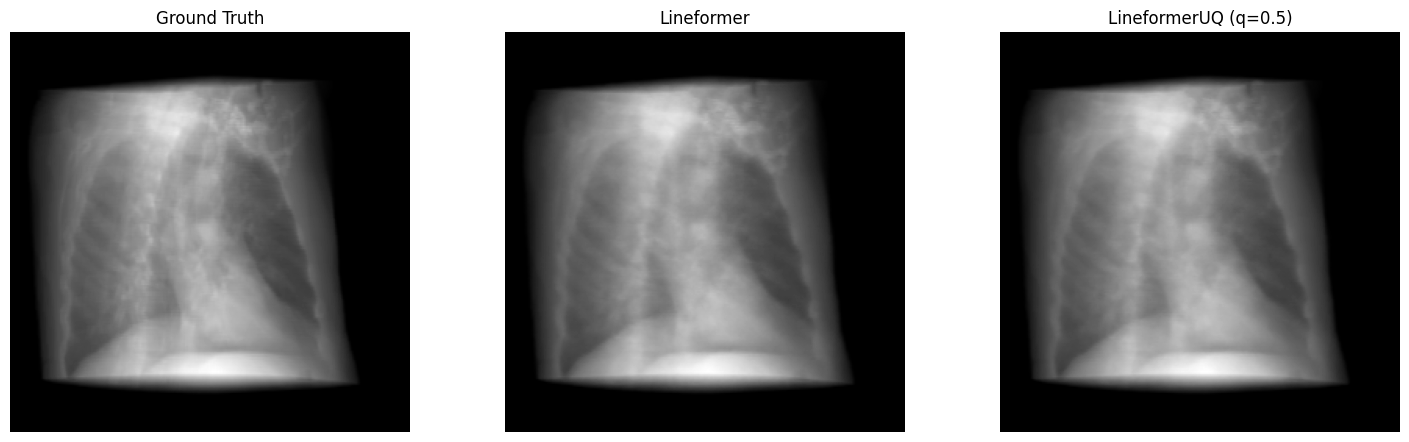

View idx in split: 1


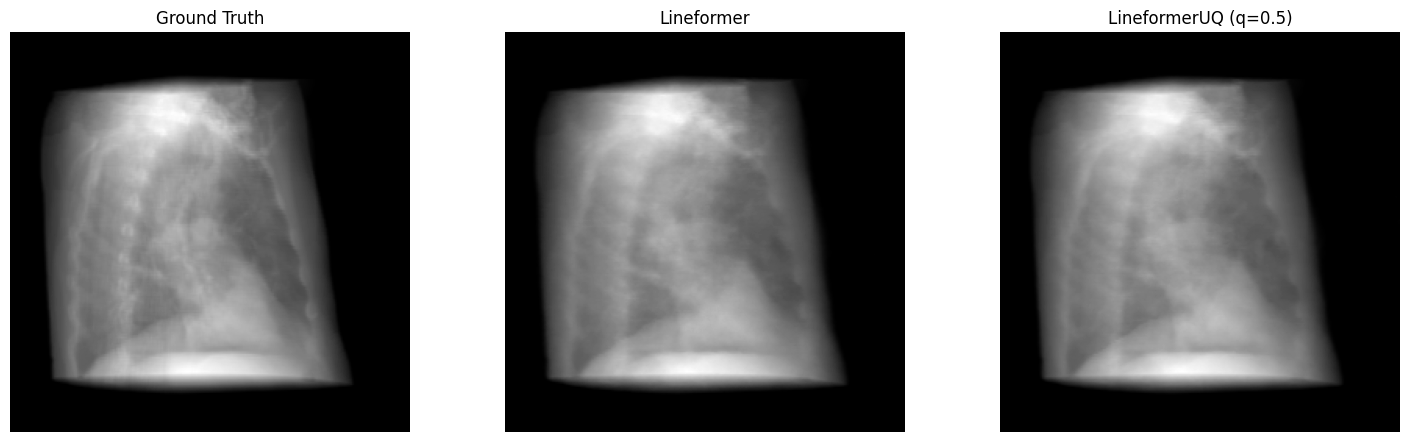

View idx in split: 2


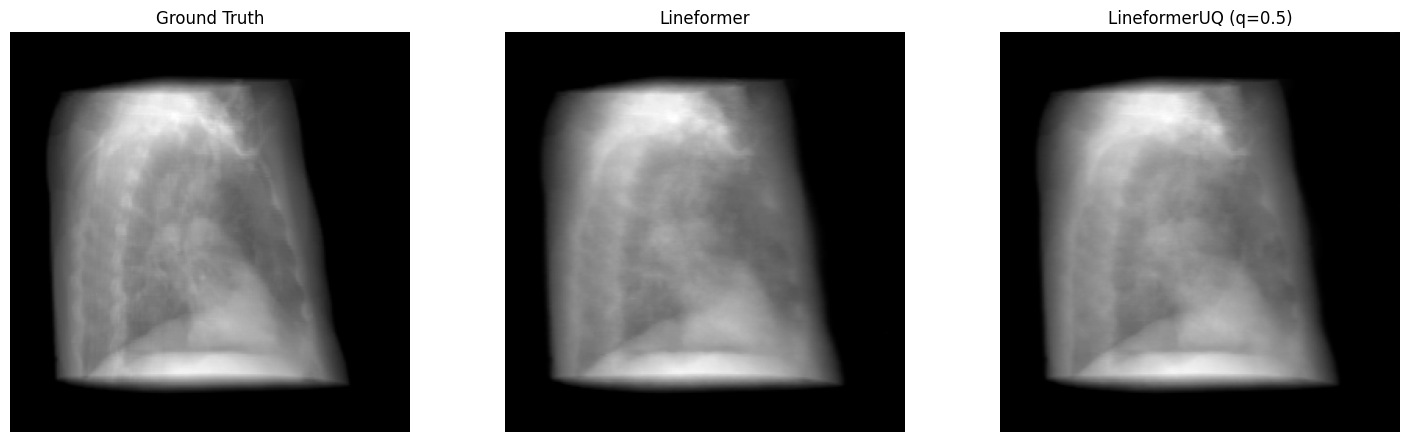

View idx in split: 3


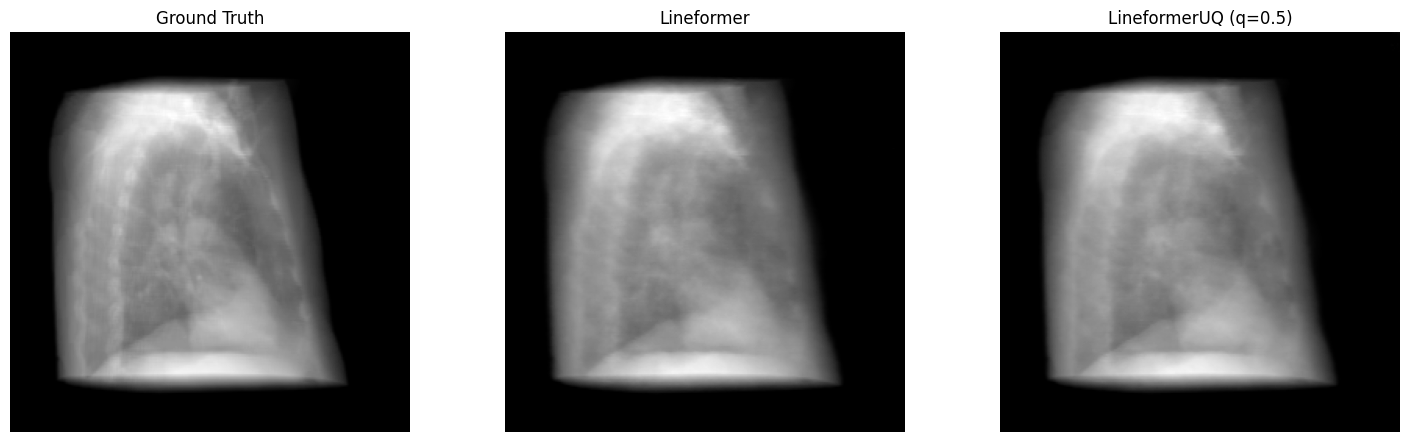

In [15]:
def show_triplet(gt, pred_a, pred_b, title_a='Lineformer', title_b='LineformerUQ'):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    axes[0].imshow(cast_to_image(gt).squeeze(), cmap='gray')
    axes[0].set_title('Ground Truth')
    axes[1].imshow(cast_to_image(pred_a).squeeze(), cmap='gray')
    axes[1].set_title(title_a)
    axes[2].imshow(cast_to_image(pred_b).squeeze(), cmap='gray')
    axes[2].set_title(title_b)
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

num_show = min(4, len(sel_idx))
for i in range(num_show):
    print(f'View idx in split: {sel_idx[i]}')
    show_triplet(
        projs_eval[i],
        pred_std[i],
        pred_uq[i],
        title_a='Lineformer',
        title_b=f'LineformerUQ (q={Q_VALUE})',
    )

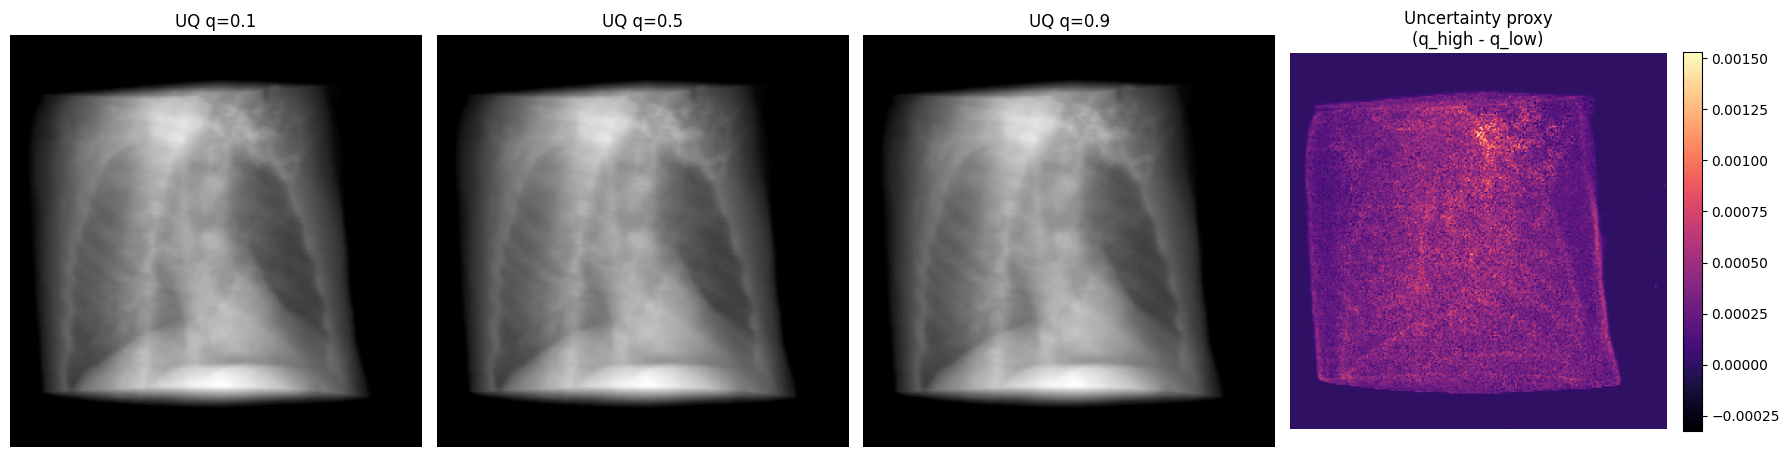

In [16]:
# UQ uncertainty visualization for one selected view
q_sorted = sorted(uq_multiq.keys())
q_low, q_mid, q_high = q_sorted[0], q_sorted[len(q_sorted)//2], q_sorted[-1]
pred_low = uq_multiq[q_low]
pred_mid = uq_multiq[q_mid]
pred_high = uq_multiq[q_high]
interval_width = pred_high - pred_low

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes[0].imshow(cast_to_image(pred_low).squeeze(), cmap='gray')
axes[0].set_title(f'UQ q={q_low}')
axes[1].imshow(cast_to_image(pred_mid).squeeze(), cmap='gray')
axes[1].set_title(f'UQ q={q_mid}')
axes[2].imshow(cast_to_image(pred_high).squeeze(), cmap='gray')
axes[2].set_title(f'UQ q={q_high}')
im = axes[3].imshow(interval_width.detach().cpu().numpy(), cmap='magma')
axes[3].set_title('Uncertainty proxy\n(q_high - q_low)')
fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

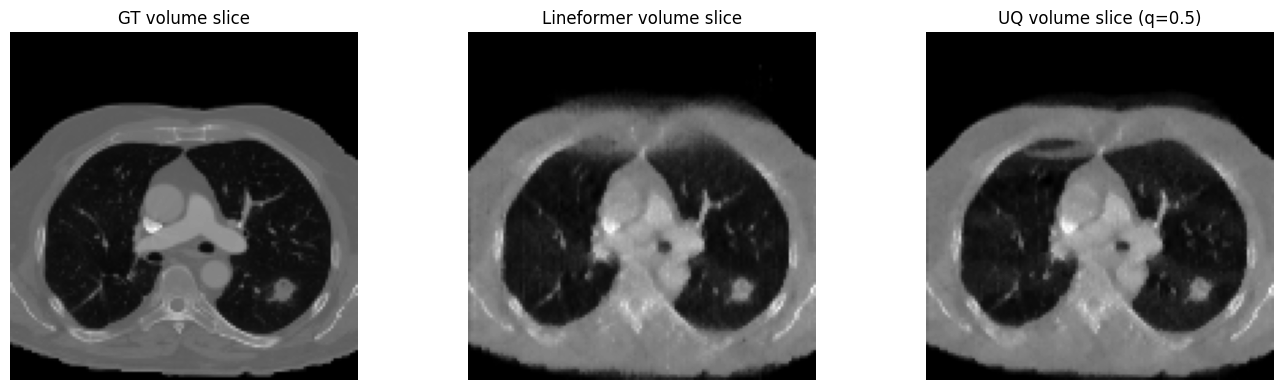

In [17]:
# Optional 3D slice visualization (if VOXEL_EVAL=True)
if VOXEL_EVAL and pred_vol_std is not None and pred_vol_uq is not None:
    gt_vol = split_data['image']
    z = gt_vol.shape[-1] // 2

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(cast_to_image(gt_vol[..., z]).squeeze(), cmap='gray')
    axes[0].set_title('GT volume slice')
    axes[1].imshow(cast_to_image(pred_vol_std[..., z]).squeeze(), cmap='gray')
    axes[1].set_title('Lineformer volume slice')
    axes[2].imshow(cast_to_image(pred_vol_uq[..., z]).squeeze(), cmap='gray')
    axes[2].set_title(f'UQ volume slice (q={Q_VALUE})')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 7) Notes and caveats

- `val` split is fully native to `TIGREDataset`; `cal` support is adapted in-notebook using the same geometry/ray equations from `src/dataset/tigre.py`.
- Split schema is inferred from your snippet (`angles`, `projections` in `train`/`val`/`cal`). If your pickle includes different key names, update the loading cell.
- Checkpoints are assumed to store `network` and optional `network_fine` like training scripts (`train.py`/`train_mlg.py`).
- UQ inference path requires passing quantiles to renderer (`render(..., quantiles=q_chunk)`) and voxel inference (`run_network(..., quantiles=vox_q)`).
- Some repo scripts are CLI-oriented; this notebook refactors those flows into callable cells while keeping function paths and behavior aligned.
- If your UQ checkpoint was initialized from deterministic weights, `load_state_dict(strict=False)` may report missing `quantile_embed.*` keys during warm start; this is expected depending on checkpoint provenance.